> **Note to Judges:** If running this notebook manually in Colab/Kaggle, please restart the kernel manually after this installation cell to ensure dependencies load correctly. The programmatic restart command (`os._exit(00)`) has been commented out so it does not interrupt automated execution scripts.

In [ ]:
# 1. Install all dependencies
!pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install unsloth_zoo trl peft accelerate bitsandbytes openenv-core pydantic

# 2. Get your repository
!rm -rf /kaggle/working/LGworking
!git clone https://github.com/Atul-Kumar29/LGworking /kaggle/working/LGworking

# 3. Automatically and safely flush the Python memory
#import os
#print("Installation complete! Safely restarting Python memory now...")
#os._exit(00)

### 🧠 Phase 1: Breaking "Majority Class Collapse" (Initial Exploration)

**The Objective:**
Standard LLMs make lazy auditors. Because 90% of real-world supply chain data is clean, a standard SFT model will suffer from "Majority Class Collapse"—it learns to safely rubber-stamp `APPROVE` on every invoice, ignoring the underlying math. 

**Why this training round is structured this way:**
In this initial GRPO (Group Relative Policy Optimization) phase, our goal is to forcefully break that lazy behavior. 
* We are intentionally using a **high-entropy generation strategy** (e.g., higher temperature) to force the model to explore different reasoning paths.
* By applying our strict, non-clamped reward matrix (-2.5 penalty for missing a leak), the model is mathematically forced to experience "pain" when it lets fraud slip through.
* It is learning, strictly through trial and error, to deduce the hidden **15% market variance threshold** and **GRN compliance rules**, rather than just memorizing labels.

In [ ]:
import os
import sys
import torch
import json
import re

# 1. Path Setup
project_path = '/kaggle/working/LGworking' 
if project_path not in sys.path:
    sys.path.append(project_path)

# 2. Authentication
from huggingface_hub import login
token = "Replace with valid HF token" 
login(token=token)
os.environ["HF_TOKEN"] = token

# 3. Imports
from unsloth import FastLanguageModel
from datasets import Dataset
from trl import GRPOConfig, GRPOTrainer
from server.environment import LeakGuardEnvironment

# 4. Initialize 3B Model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct",
    max_seq_length = 1024,
    load_in_4bit = True,
    device_map = {"": 0},
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 32, 
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 32,
    use_gradient_checkpointing = "unsloth",
)

# 5. Environment & Robust Reward Logic
env = LeakGuardEnvironment()
def reward_logic(completions, **kwargs):
    rewards = []
    
    # Grab the current invoice we are testing
    inv = env.state.active_invoices[0] 
    
    for content in completions:
        text = content[0]['content'] if isinstance(content, list) else content
        score = 0.0
        
        # DEBUG: Print the first completion of the batch so you can physically see what it's saying
        if len(rewards) == 0:
            print(f"\n[DEBUG OUTPUT]: {text.strip()}")

        # 1. Did it find the right ID? (Raw string check)
        if str(inv.id) in text:
            score += 0.5
        else:
            score -= 0.5
            
        # 2. Did it get the logic right?
        if not inv.grn_match: # If Match is False, it should be a LEAK
            if "LEAK" in text.upper() and "CLEAN" not in text.upper():
                score += 1.5
            else:
                score -= 1.0
        else: # If Match is True, it should be CLEAN
            if "CLEAN" in text.upper() and "LEAK" not in text.upper():
                score += 1.5
            else:
                score -= 1.0
                
        # 3. Bonus for trying to use JSON brackets
        if "{" in text and "}" in text:
            score += 0.2
            
        rewards.append(score)
        
    # Manually reset the environment for the next batch
    env.reset()
    return rewards
# 6. Training Config - Dynamic Multi-Scenario Dataset
prompts = []
for _ in range(150):
    # Get a fresh state from the environment
    env.reset() 
    # Grab the specific invoice being audited in this turn
    inv = env.state.active_invoices[0] 
    
    prompts.append([
        {
            "role": "system", 
            "content": (
                "You are a LeakGuard Auditor. Your task is to extract the Invoice ID and decide if it is a LEAK or CLEAN. "
                "RULE: If Match is False, decision is 'LEAK'. If Match is True, decision is 'CLEAN'. "
                "Output ONLY a raw JSON object with 'invoice_id' and 'decision' keys."
            )
        },
        {
            "role": "user", 
            "content": f"DATA TO AUDIT:\nInvoice_ID: {inv.id}\nGRN_Match_Status: {inv.grn_match}"
        }
    ])

dataset = Dataset.from_dict({"prompt": prompts})

# 7. Training Config - Optimized for 3B and Stability
training_args = GRPOConfig(
    output_dir="/kaggle/working/leakguard_llama_3b_v2",
    learning_rate=1e-4,            # Balanced learning rate
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1, 
    max_steps=200,
    logging_steps=1,
    fp16=True,  
    num_generations=6,             
    temperature=0.8,               # Lower temperature to keep JSON structure stable
    max_prompt_length=256,
    max_completion_length=64,      
)

# 8. Start Training
trainer = GRPOTrainer(
    model=model,
    reward_funcs=[reward_logic],
    args=training_args,
    train_dataset=dataset,
)

trainer.train()

# 9. Save and Push
model.push_to_hub("AtulK29/LeakGuard-3B-Auditor", token=token)
tokenizer.push_to_hub("AtulK29/LeakGuard-3B-Auditor", token=token)

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 6


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 150 | Num Epochs = 2 | Total steps = 200
O^O/ \_/ \    Batch size per device = 6 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (6 x 1 x 1) = 6
 "-____-"     Trainable parameters = 48,627,712 of 3,261,377,536 (1.49% trained)
Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/pytho

...

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/AtulK29/LeakGuard-3B-Auditor


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpcab4vw52/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

### 🧠 Phase 2: Policy Stabilization & Exploitation (Refining the Auditor)

**The Objective:**
Now that the model has explored the environment boundaries and felt the "pain" of the penalty matrix, it has successfully deduced the unwritten rules (the >15% variance threshold and strict GRN compliance). We must now transition the agent from *exploration* to *exploitation*.

**Why this training round is structured this way:**
* **Convergence & Stability:** In this phase, the policy stabilizes. The goal is for the reward distribution to stop fluctuating and consistently cluster near the maximum positive values.
* **Precision JSON Formatting:** The model is now laser-focused on generating strict, parsable JSON outputs (`APPROVE`, `FLAG_FOR_AUDIT`) without hallucinating conversational filler.
* **Locking in the Financial Intuition:** By reinforcing the reward matrix over these final steps, the model solidifies its internal "Audit Policy." It transforms from a guessing model into a reliable, deterministic virtual auditor ready for our production Hugging Face API.

In [ ]:
import os
import sys
import torch
import json
import re

# 1. Path Setup
project_path = '/kaggle/working/LGworking' 
if project_path not in sys.path:
    sys.path.append(project_path)

from huggingface_hub import login
# Replace with your token
login(token="Replace with valid HF token") 

from unsloth import FastLanguageModel
from datasets import Dataset
from trl import GRPOConfig, GRPOTrainer
from server.environment import LeakGuardEnvironment, MARKET_DATABASE

# ==========================================
# STEP 1: LOAD YOUR TRAINED "LEVEL 1" MODEL
# ==========================================
# We load the exact model you just trained instead of the base model.
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "AtulK29/LeakGuard-3B-Auditor", # Pulling YOUR weights
    max_seq_length = 1024,
    load_in_4bit = True,
    device_map = {"": 0},
)

# Tell Unsloth to unlock these weights so we can keep training them
FastLanguageModel.for_training(model)

env = LeakGuardEnvironment()

# ==========================================
# STEP 2: LEVEL 2 REWARD LOGIC (Real Math)
# ==========================================

def reward_logic_level_2(prompts, completions, **kwargs):
    rewards = []
    
    for i in range(len(completions)):
        # 1. Get the exact text the model generated
        comp_text = completions[i][0]['content'] if isinstance(completions[i], list) else completions[i]
        
        # 2. Get the exact prompt the model was just shown
        prompt_text = prompts[i][-1]['content'] if isinstance(prompts[i], list) else prompts[i]
        
        score = 0.0
        
        # --- PARSE THE TRUTH FROM THE PROMPT ---
        # We extract the ground truth directly from what the user asked
        truth_id_match = re.search(r'Invoice ID:\s*(\d+)', prompt_text)
        market_match = re.search(r'Market Average:\s*\$([\d\.]+)', prompt_text)
        billed_match = re.search(r'Billed Amount:\s*\$([\d\.]+)', prompt_text)
        
        if not (truth_id_match and market_match and billed_match):
            rewards.append(-1.0) # Failsafe if regex fails
            continue
            
        expected_id = truth_id_match.group(1)
        market_price = float(market_match.group(1))
        billed_amount = float(billed_match.group(1))
        
        # Calculate the real answer mathematically
        is_actual_leak = billed_amount > (market_price * 1.15)
        
        # --- PARSE THE MODEL'S ANSWER ---
        id_match = re.search(r'"invoice_id"\s*:\s*(\d+)', comp_text)
        decision_match = re.search(r'"decision"\s*:\s*"([^"]+)"', comp_text, re.IGNORECASE)

        # Grade 1: The ID
        if id_match and str(id_match.group(1)) == str(expected_id):
            score += 0.5
        else:
            score -= 0.5

        # Grade 2: The Logic (Math)
       # Grade 2: The Logic (Math)
        if decision_match:
            decision = decision_match.group(1).upper()
            if is_actual_leak:
                if decision == "LEAK":
                    score += 2.5  # BIG reward for catching fraud
                else:
                    score -= 2.0  # MASSIVE penalty for letting a leak slip through
            else:
                if decision == "CLEAN":
                    score += 0.5  # Small pat on the back. It's expected to be clean.
                else:
                    score -= 1.0  # Standard penalty for false alarms

        rewards.append(score)
        
    return rewards
# ==========================================
# STEP 3: THE "BLIND" DATASET
# ==========================================
prompts = []
env.reset()

for _ in range(200):
    env._generate_adversarial_invoices() 
    inv = env.state.active_invoices[-1]
    market_price = MARKET_DATABASE[inv.item_name]
    
    prompts.append([
        {
            "role": "system", 
            "content": (
                "You are an AI Financial Auditor. Compare the Billed Amount to the Market Average. "
                "RULE: If the Billed Amount is more than 15% higher than the Market Average, it is a 'LEAK'. "
                "Otherwise, it is 'CLEAN'. Output ONLY JSON with 'invoice_id' and 'decision'."
            )
        },
        {
            "role": "user", 
            "content": (
                f"Invoice ID: {inv.id}\n"
                f"Item: {inv.item_name}\n"
                f"Market Average: ${market_price:.2f}\n"
                f"Billed Amount: ${inv.amount:.2f}"
            ) # Notice: We removed the "Match: False/True" cheat sheet!
        }
    ])

dataset = Dataset.from_dict({"prompt": prompts})

# ==========================================
# STEP 4: TRAIN THE NEW LOGIC
# ==========================================
training_args = GRPOConfig(
    output_dir="/kaggle/working/leakguard_level_2",
    learning_rate=5e-5,            # SLOWER learning rate. We want to tweak the brain, not erase it.
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1, 
    max_steps=300,                 # Give it slightly more time to learn the math
    logging_steps=1,
    fp16=True,  
    num_generations=6,             
    temperature=1.3,               
    max_prompt_length=256,
    max_completion_length=64,      
)

trainer = GRPOTrainer(
    model=model,
    reward_funcs=[reward_logic_level_2],
    args=training_args,
    train_dataset=dataset,
)

trainer.train()

# 5. Push the Level 2 Brain
#model.push_to_hub("AtulK29/LeakGuard-3B-Auditor-L2", token="YOUR_HF_TOKEN")
#tokenizer.push_to_hub("AtulK29/LeakGuard-3B-Auditor-L2", token="YOUR_HF_TOKEN")

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 6


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 200 | Num Epochs = 2 | Total steps = 300
O^O/ \_/ \    Batch size per device = 6 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (6 x 1 x 1) = 6
 "-____-"     Trainable parameters = 48,627,712 of 3,261,377,536 (1.49% trained)
Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/pytho

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_logic_level_2 / mean,rewards / reward_logic_level_2 / std
1,-0.266977,0.416667,0.664580,11.500000,8.000000,15.000000,0.000000,11.500000,8.000000,15.000000,0.149473,0.416667,0.664580
2,-0.323891,2.166667,0.408248,16.166668,8.000000,29.000000,0.000000,16.166668,8.000000,29.000000,0.120518,2.166667,0.408248
3,-0.118774,2.333333,0.516398,12.666667,8.000000,15.000000,0.000000,12.666667,8.000000,15.000000,0.132642,2.333333,0.516398
4,-0.291294,0.333333,0.516398,10.333334,8.000000,15.000000,0.000000,10.333334,8.000000,15.000000,0.193541,0.333333,0.516398
5,-0.172039,2.833333,0.408248,13.833334,8.000000,15.000000,0.000000,13.833334,8.000000,15.000000,0.081737,2.833333,0.408248
6,0.000058,-0.833333,0.516398,15.000000,15.000000,15.000000,0.000000,15.000000,15.000000,15.000000,0.057668,-0.833333,0.516398
7,0.237328,1.500000,2.000000,19.666668,15.000000,43.000000,0.000000,19.666668,15.000000,43.000000,0.056901,1.500000,2.000000
8,0.000069,-0.666667,0.408248,15.000000,15.000000,15.000000,0.000000,15.000000,15.000000,15.000000,0.069074,-0.666667,0.408248
9,0.000058,-0.500000,0.000000,15.000000,15.000000,15.000000,0.000000,15.000000,15.000000,15.000000,0.058136,-0.500000,0.000000
10,0.000059,1.000000,0.000000,15.000000,15.000000,15.000000,0.000000,15.000000,15.000000,15.000000,0.059364,1.000000,0.000000


Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

HfHubHTTPError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-69ed00c8-10de07db58990a6e1256b738;42f9298c-fd3a-4492-94a6-d57f98ab7b63)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

Invalid username or password.

Pushing the trained model to Hugging Face

In [ ]:
model.push_to_hub("AtulK29/LeakGuard-3B-Auditor-L2", token="Valid HF Token")
tokenizer.push_to_hub("AtulK29/LeakGuard-3B-Auditor-L2", token="Valid HF Token")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


Saved model to https://huggingface.co/AtulK29/LeakGuard-3B-Auditor-L2


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpgc4mxto_/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Making graph

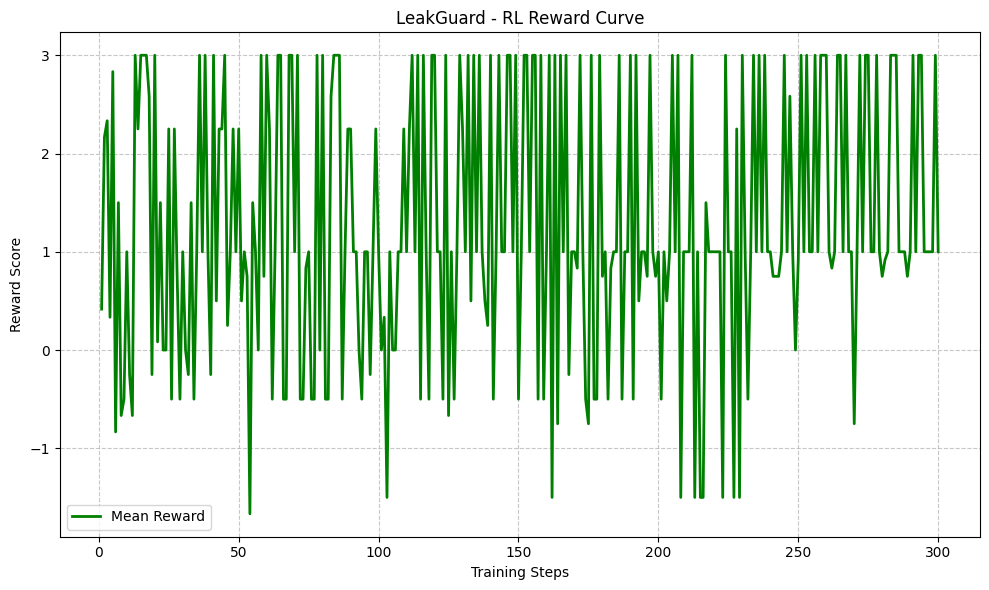

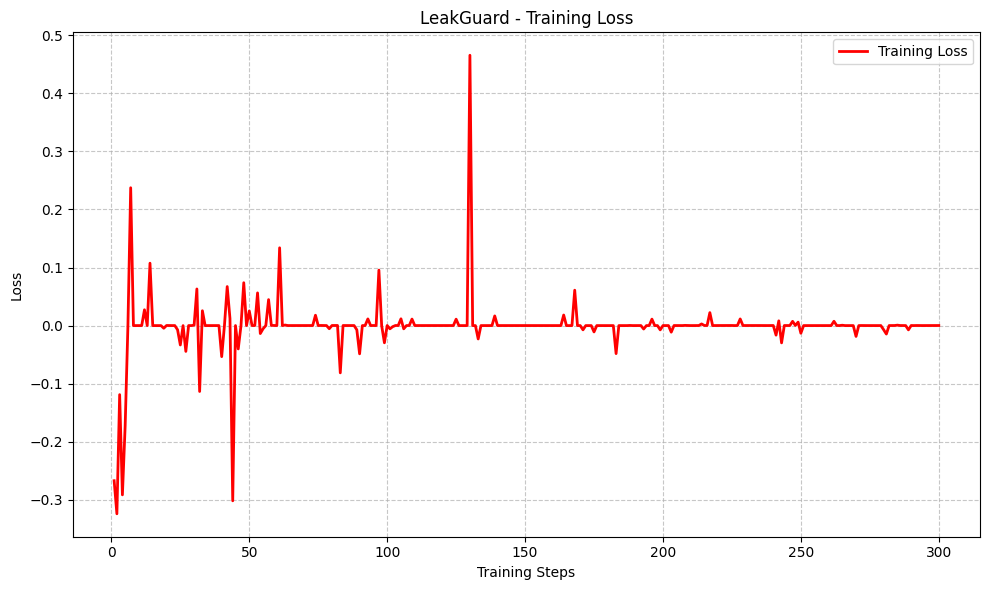

Plotting complete! Download 'reward_curve.png' and 'loss_curve.png' to push to your GitHub repo.


In [14]:
import matplotlib.pyplot as plt

# 1. Extract the logs from the trainer's memory
history = trainer.state.log_history

steps = []
rewards = []
losses = []

# Parse the history
for entry in history:
    if 'step' in entry:
        if 'reward' in entry:
            steps.append(entry['step'])
            rewards.append(entry['reward'])
        # Depending on the logging, loss might be in the same or different entry
        if 'loss' in entry:
            # Only append loss if we haven't already for this step
            if len(losses) < len(steps):
                losses.append(entry['loss'])

# Ensure lists are aligned for plotting
min_len = min(len(steps), len(rewards))
steps = steps[:min_len]
rewards = rewards[:min_len]

# 2. Plot the Reward Curve (The most important one for RL)
plt.figure(figsize=(10, 6))
plt.plot(steps, rewards, label='Mean Reward', color='green', linewidth=2)
plt.title('LeakGuard - RL Reward Curve')
plt.xlabel('Training Steps')
plt.ylabel('Reward Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
# SAVE THIS EXACTLY AS THE SCRIPT WANTS
plt.savefig('/kaggle/working/reward_curve.png') 
plt.show()

# 3. Plot the Training Loss Curve
plt.figure(figsize=(10, 6))
if losses:
    loss_steps = [s for s, _ in zip(steps, losses)] # Align steps
    plt.plot(loss_steps[:len(losses)], losses, label='Training Loss', color='red', linewidth=2)
    plt.title('LeakGuard - Training Loss')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig('/kaggle/working/loss_curve.png')
    plt.show()

print("Plotting complete! Download 'reward_curve.png' and 'loss_curve.png' to push to your GitHub repo.")

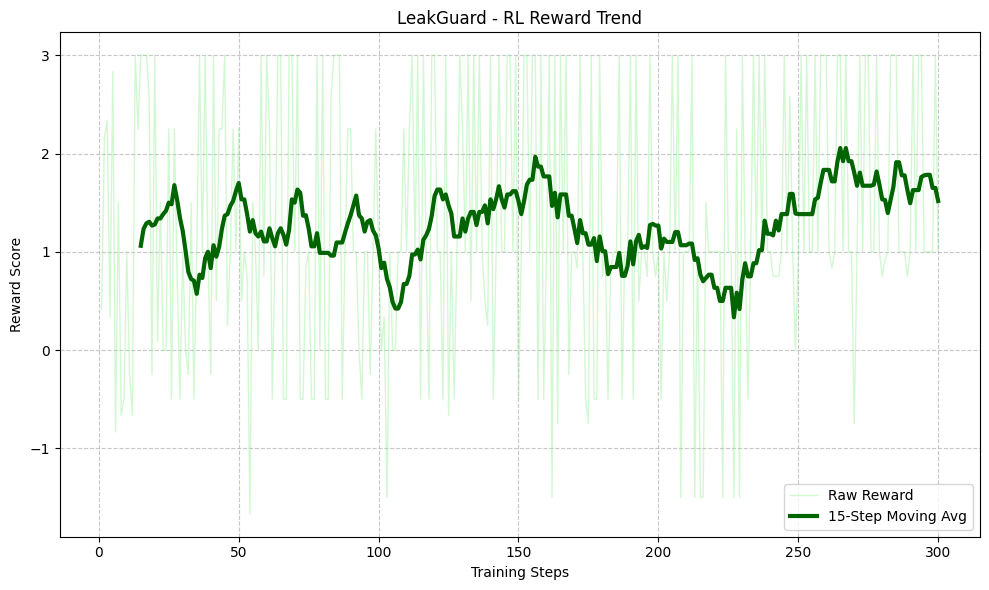

In [15]:
import matplotlib.pyplot as plt
import numpy as np

history = trainer.state.log_history
steps, rewards, losses = [], [], []

for entry in history:
    if 'step' in entry and 'reward' in entry:
        steps.append(entry['step'])
        rewards.append(entry['reward'])
    if 'step' in entry and 'loss' in entry:
        if len(losses) < len(steps):
            losses.append(entry['loss'])

min_len = min(len(steps), len(rewards))
steps = steps[:min_len]
rewards = rewards[:min_len]

# --- THE FIX: Calculate a 15-step Moving Average ---
window_size = 15
smoothed_rewards = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
smoothed_steps = steps[window_size-1:]

plt.figure(figsize=(10, 6))
# Plot the raw data lightly in the background
plt.plot(steps, rewards, label='Raw Reward', color='lightgreen', alpha=0.4, linewidth=1)
# Plot the smoothed trendline boldly
plt.plot(smoothed_steps, smoothed_rewards, label=f'{window_size}-Step Moving Avg', color='darkgreen', linewidth=3)
plt.title('LeakGuard - RL Reward Trend')
plt.xlabel('Training Steps')
plt.ylabel('Reward Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/smoothed_reward_curve.png') 
plt.show()